## LIBRARIES

In [1]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import shutil
import random
import matplotlib.pyplot as plt
import numpy as np
import cv2
import numpy as np
import tensorflow as tf


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Data generators for training, validation, and testing

## DATA PREPROCESSING

### - DATA AUGUMENTATION

In [5]:
img_size = (224, 224)
batch_size = 32

In [6]:
train_dir = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\FINAL_TO_BE_USED\combined_dataset_split - Copy\train"
val_dir = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\FINAL_TO_BE_USED\combined_dataset_split - Copy\val"
test_dir = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\FINAL_TO_BE_USED\combined_dataset_split - Copy\test"

In [7]:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     horizontal_flip=True,
#     rotation_range=10,
#     zoom_range=0.1

#Another Type : 
 # train_gen = ImageDataGenerator(
    # rescale=1./255,
    # rotation_range=20,
    # zoom_range=0.2,
    # width_shift_range=0.1,
    # height_shift_range=0.1,
    # horizontal_flip=True

#Another Type with brightness adjustments:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,  # Reduce rotation (skin features are orientation-sensitive)
#     width_shift_range=0.1,  # Reduce shifts
#     height_shift_range=0.1,
#     zoom_range=0.15,  # Slight zoom
#     shear_range=0.1,  # Reduce shear
#     horizontal_flip=True,
#     brightness_range=[0.8, 1.2],  # Add brightness variation (important for skin)
#     fill_mode='nearest'
# )


### - LOAD DATASETS

In [8]:
datagen = ImageDataGenerator(rescale=1./255)

In [9]:
print("Training data loaded")
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
print("Validation data loaded")
val_data = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'  
)
print("Testing data loaded")
test_data = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)
print(" ")

# The ouput indicates the number of images in each set and the classes(Dry, Oily and Normal) detected in the dataset.

print(train_data.class_indices)
print(val_data.class_indices)
print(test_data.class_indices)

Training data loaded
Found 18140 images belonging to 3 classes.
Validation data loaded
Found 1360 images belonging to 3 classes.
Testing data loaded
Found 1362 images belonging to 3 classes.
 
{'Dry': 0, 'Normal': 1, 'Oily': 2}
{'Dry': 0, 'Normal': 1, 'Oily': 2}
{'Dry': 0, 'Normal': 1, 'Oily': 2}


In [10]:
print(f"Total training images: {train_data.samples}")
print(f"Total validation images: {val_data.samples}")
print(f"Total testing images: {test_data.samples}")
total = train_data.samples + val_data.samples + test_data.samples
print(f"Total dataset: {total}")

Total training images: 18140
Total validation images: 1360
Total testing images: 1362
Total dataset: 20862


(32, 224, 224, 3)


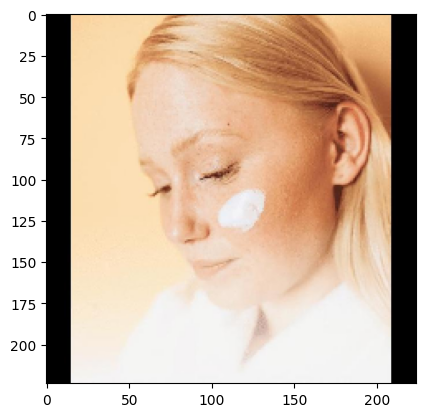

(32, 224, 224, 3)


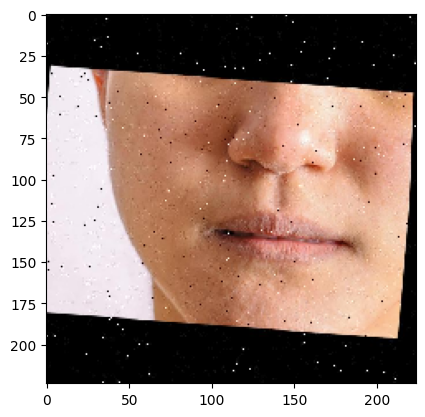

In [11]:
for _ in range(2):
    img, label = next(train_data)
    print(img.shape)
    plt.imshow(img[0])
    plt.show()

## MODEL - MobileNetV2

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [14]:
#Freezing the base model :
# Why to freeze?
# - Prevents MobileNetV2 weights from changing
# - Preserves learned features (edges, textures, skin patterns)
# - Faster training
# - Prevents overfitting (important for small/imbalanced data)

base_model.trainable = False


#Last layers Unfreeze
# base_model.trainable = True

# for layer in base_model.layers[:-40]:
#     layer.trainable = False


In [19]:
#To see which layers are trainable
for layer in base_model.layers:
    print(layer.name, layer.trainable)


input_layer False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_dep

In [ ]:
# Original
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])


In [ ]:
# model = models.Sequential([
#     layers.Input(shape=(224, 224, 3)),
#     # DATA AUGMENTATION: This is the secret to making lines touch
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.2),
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dropout(0.5), # High dropout prevents the gap
#     layers.Dense(3, activation='softmax')
# ])


In [ ]:
# x = base_model.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(64, activation='relu')(x)
# x = Dropout(0.5)(x)
# output = Dense(train_data.num_classes, activation='softmax')(x)

# model = Model(inputs=base_model.input, outputs=output)


### Way to add Gaussian Noise in case of overfitting

In [ ]:
# from tensorflow.keras.layers import GaussianNoise, Input
# from tensorflow.keras.models import Model
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# input_layer = Input(shape=(224,224,3))

# # Add noise to input images
# x = GaussianNoise(0.05)(input_layer)

# # Base model
# base_model = MobileNetV2(weights="imagenet", include_top=False, input_tensor=x)
# x = base_model.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(128, activation="relu")(x)
# output = Dense(3, activation="softmax")(x)

# model = Model(inputs=input_layer, outputs=output)


## COMPILE THE MODEL

In [21]:
# Original
model.compile(
    optimizer="Adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# model.compile(
#     optimizer="Adam",
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## TRAINING THE MODEL

### - Build 1


In [23]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    # callbacks=[early_stop]
)

c:\Users\khati\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 535s 936ms/step - accuracy: 0.4959 - loss: 1.0349 - val_accuracy: 0.6162 - val_loss: 0.8128
Epoch 2/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 516s 910ms/step - accuracy: 0.6261 - loss: 0.8048 - val_accuracy: 0.6721 - val_loss: 0.7421
Epoch 3/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 600s 1s/step - accuracy: 0.6739 - loss: 0.7199 - val_accuracy: 0.7066 - val_loss: 0.6820
Epoch 4/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.7128 - loss: 0.6442 - val_accuracy: 0.7250 - val_loss: 0.6436
Epoch 5/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.7471 - loss: 0.5777 - val_accuracy: 0.7537 - val_loss: 0.5788
Epoch 6/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 566s 997ms/step - accuracy: 0.7675 - loss: 0.5301 - val_accuracy: 0.7816 - val_loss: 0.5395
Epoch 7/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 529s 932ms/step - accuracy: 0.7983 - loss: 0.4661 - val_accuracy: 0.7838 - val_loss: 0.5468
Epoch 8/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 496s 875ms/step - accuracy: 0.8142 - loss: 0.

## TRAINING VS VALIDATION ( ACCURACY )

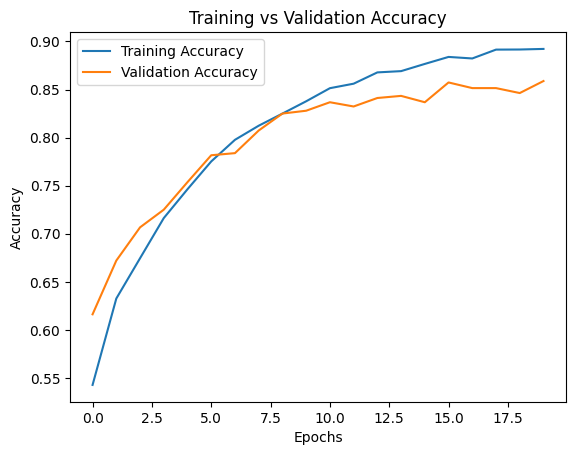

In [24]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.show()

## TRAINING VS VALIDATION ( LOSS )

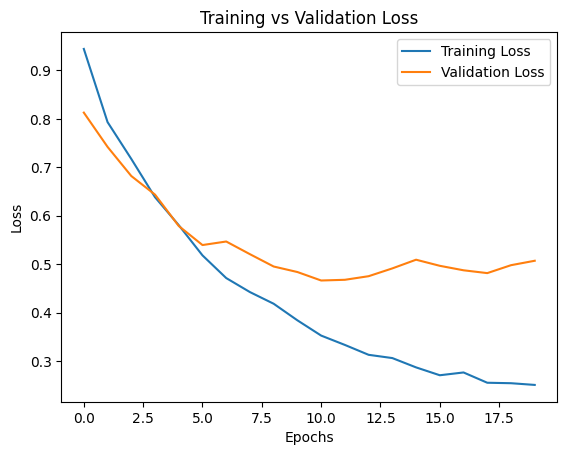

In [25]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()


In [26]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8970 - loss: 0.2801
Test Accuracy: 0.93098384141922
Test Loss: 0.19763709604740143


In [27]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8546 - loss: 0.5282
Validation Accuracy: 0.8588235378265381
Validation Loss: 0.5070903897285461


In [34]:
model.save("skin_type_mobilenetv2_final.h5")

In [28]:
pred = model.predict(test_data)
y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['dry','normal','oily']))

43/43 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step
Confusion Matrix:
[[369  17  23]
 [ 16 457  19]
 [  8  11 442]]

Classification Report:
              precision    recall  f1-score   support

         dry       0.94      0.90      0.92       409
      normal       0.94      0.93      0.94       492
        oily       0.91      0.96      0.94       461

    accuracy                           0.93      1362
   macro avg       0.93      0.93      0.93      1362
weighted avg       0.93      0.93      0.93      1362



## CONFUSION MATRIX

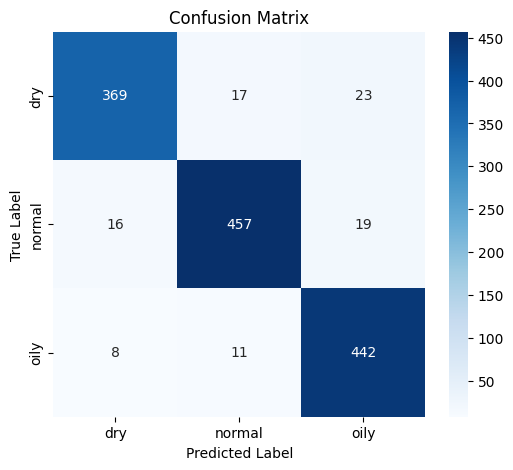

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
class_names = ['dry', 'normal', 'oily']

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## FINE-TUNING

### - UNFREEZE THE LAST LAYERS AND TRAIN AGAIN


In [35]:
base_model.trainable = True


In [36]:
len(base_model.layers)

154

In [37]:
finetune_at = 145

In [38]:
for layer in base_model.layers[:finetune_at]:
    layer.trainable = False

In [39]:
print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers: {len(model.trainable_variables)}")

Total layers in base model: 154
Trainable layers: 13


In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    dropout=0.5
)


In [41]:
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name} | Trainable: {layer.trainable}")

# Or simply look at the summary
model.summary()
# Look at 'Trainable params' vs 'Non-trainable params' at the bottom

Layer 0: mobilenetv2_1.00_224 | Trainable: True
Layer 1: global_average_pooling2d | Trainable: True
Layer 2: dense | Trainable: True
Layer 3: dropout | Trainable: True
Layer 4: dense_1 | Trainable: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 894,915 (3.41 MB)

 Non-trainable params: 1,527,424 (5.83 MB)

### - Early Stopping

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# lr_reduce = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.3,
#     patience=3,
#     min_lr=1e-6
# )

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_reduce]   
)

## Save the model

In [ ]:
model.save("skin_type_mobilenetv2_final.h5")